Dieser Codeblock führt eine **externe Modellvalidierung** durch, bei der mehrere Klassifikationsmodelle auf dem **Motum-Datensatz trainiert** und anschließend auf dem **Maestroni-Datensatz getestet** werden:

- lädt den internen **Trainingsdatensatz (Motum)** und den externen **Testdatensatz (Maestroni)**,
- behält nur die **gemeinsamen numerischen Features** in identischer Reihenfolge,
- trainiert mehrere Modelle in einer Pipeline aus **Median-Imputation**, **MinMax-Skalierung** und **Klassifikator**,
- berechnet auf dem externen Datensatz die Kennwerte **AUROC, LogLoss und Brier Score**,
- schätzt für diese Metriken jeweils **95%-Konfidenzintervalle per stratifiziertem Bootstrap**,
- erstellt eine nach **AUROC sortierte Ergebnistabelle**,
- und visualisiert alle Modelle gemeinsam in einer **ROC-Kurve für die externe Validierung**.

Ziel ist ein **vergleichender externer Modelltest**, um zu sehen, welche Modelle auf einem unabhängigen Datensatz am besten generalisieren.

[Info] Gemeinsame Features extern (Train-Reihenfolge): 24

=== External discrimination (Maestroni) — AUROC, LogLoss, Brier (jeweils 95% KI) ===
               Model               AUROC             LogLoss               Brier
             XGBoost 0.784 (0.669–0.887) 0.699 (0.464–0.966) 0.209 (0.139–0.285)
 Logistic Regression 0.783 (0.670–0.882) 0.610 (0.532–0.688) 0.212 (0.178–0.247)
            LightGBM 0.774 (0.664–0.873) 0.662 (0.463–0.889) 0.212 (0.148–0.285)
         Extra Trees 0.719 (0.596–0.838) 0.624 (0.567–0.684) 0.217 (0.190–0.244)
       Random Forest 0.716 (0.589–0.834) 0.620 (0.548–0.695) 0.214 (0.181–0.250)
      MLP Classifier 0.707 (0.579–0.824) 2.395 (1.757–3.008) 0.365 (0.292–0.431)
Gaussian Naive Bayes 0.701 (0.579–0.818) 2.115 (1.286–3.038) 0.301 (0.205–0.399)
  Bagging Classifier 0.655 (0.527–0.774) 2.775 (1.669–3.975) 0.324 (0.243–0.409)
                 SVC 0.626 (0.490–0.751) 1.039 (1.002–1.077) 0.371 (0.361–0.381)
 k-Nearest Neighbors 0.607 (0.493–0.718) 0.993

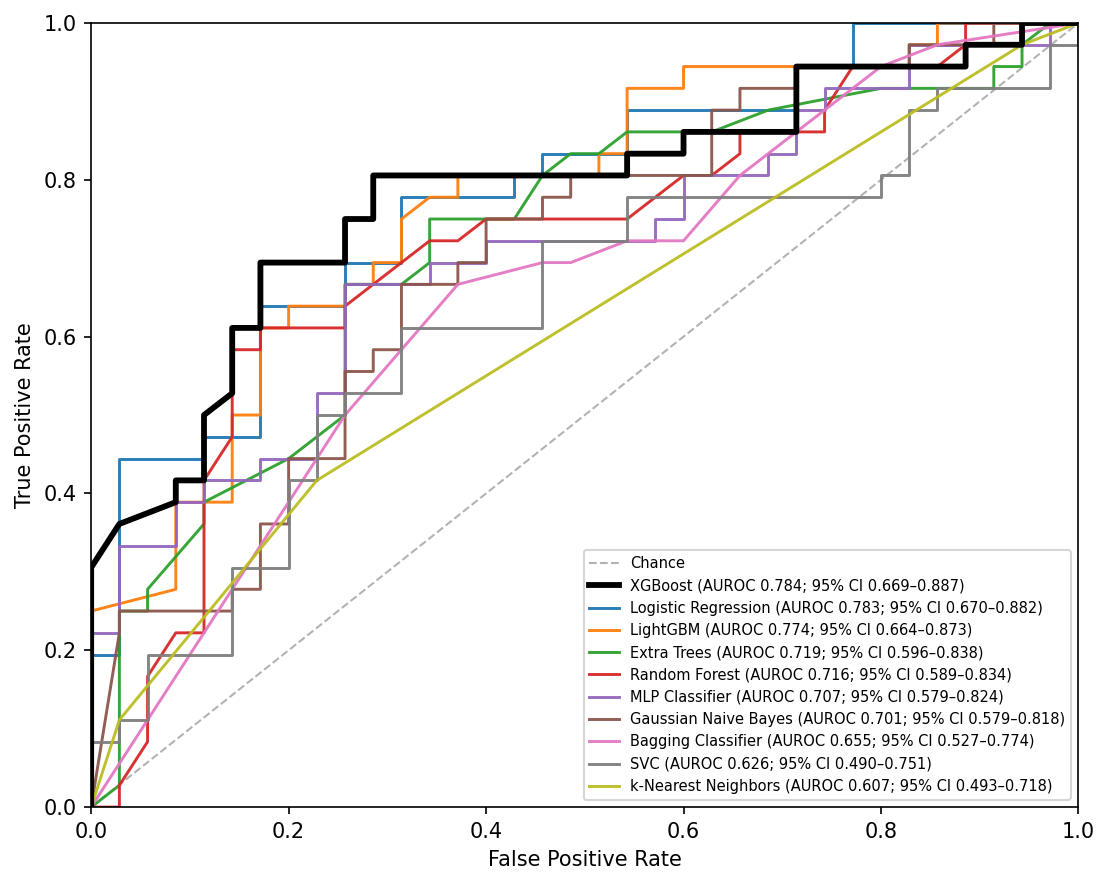

In [1]:
# ============================ EXTERNAL ROC-AUC (95% KI): Motum(train) → Maestroni(test) ============================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import roc_curve, roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression as _LR, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# XGBoost / LightGBM
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# ---- Pfade & Spalten
INTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_Motum_korrigiert.xlsx"
EXTERNAL_PATH = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_Maestroni_korrigiert.xlsx"
TARGET_COL    = "Injury status"
IGNORE_COLS   = []  # ggf. IDs hier eintragen

# ---- Modelle (LogReg wie intern: liblinear + MinMax in Pipeline)
models = {
    "Logistic Regression": LogisticRegression(solver="liblinear", penalty="l2", C=1.0,
                                              class_weight=None, max_iter=200, random_state=42),
    #"Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    #"Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False),
    "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
    "SVC": SVC(probability=True, random_state=42),
    "k-Nearest Neighbors": KNeighborsClassifier(),
    "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    #"Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
    #"Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
    "Bagging Classifier": BaggingClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
}

def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function → [0,1] gemappt; sonst Fallback."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        if s_max - s_min < 1e-12:
            return np.full_like(s, 0.5, dtype=float)
        return (s - s_min) / (s_max - s_min)
    return (model.predict(X) == 1).astype(float)

def _num_X(df: pd.DataFrame, drop_cols):
    X = df.drop(columns=drop_cols, errors="ignore").copy()
    for c in X.columns:
        if X[c].dtype == "object":
            X[c] = pd.to_numeric(X[c], errors="ignore")
    return X.select_dtypes(include=[np.number]).copy()

def bootstrap_auroc_ci(y, p, B=2000, seed=42):
    """Stratifizierter Bootstrap für AUROC (95%-KI)."""
    y = np.asarray(y).astype(int); p = np.asarray(p).astype(float)
    rng = np.random.default_rng(seed)
    idx_pos = np.where(y == 1)[0]; idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = len(idx_pos), len(idx_neg)
    aucs = []
    for _ in range(int(B)):
        s_pos = rng.choice(idx_pos, size=n_pos, replace=True)
        s_neg = rng.choice(idx_neg, size=n_neg, replace=True)
        s = np.concatenate([s_pos, s_neg])
        aucs.append(roc_auc_score(y[s], p[s]))
    lo, hi = float(np.percentile(aucs, 2.5)), float(np.percentile(aucs, 97.5))
    pt = roc_auc_score(y, p)
    return pt, lo, hi

def bootstrap_metric_ci(y, p, metric_fn, B=2000, seed=42):
    """Stratifizierter Bootstrap für beliebige Metriken (95%-KI).
    - y: binäre Labels (0/1)
    - p: Wahrscheinlichkeiten (oder kalibrierte Scores in [0,1])
    - metric_fn: Callable(y_true, p_pred) -> float
    """
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)

    rng = np.random.default_rng(seed)
    idx_pos = np.where(y == 1)[0]
    idx_neg = np.where(y == 0)[0]
    n_pos, n_neg = len(idx_pos), len(idx_neg)

    vals = []
    for _ in range(int(B)):
        s_pos = rng.choice(idx_pos, size=n_pos, replace=True)
        s_neg = rng.choice(idx_neg, size=n_neg, replace=True)
        s = np.concatenate([s_pos, s_neg])
        vals.append(metric_fn(y[s], p[s]))

    lo, hi = np.percentile(vals, [2.5, 97.5])
    pt = metric_fn(y, p)
    return float(pt), float(lo), float(hi)


# ---- Daten laden
df_tr = pd.read_excel(INTERNAL_PATH)
df_te = pd.read_excel(EXTERNAL_PATH)
if TARGET_COL not in df_tr.columns or TARGET_COL not in df_te.columns:
    raise ValueError(f"'{TARGET_COL}' fehlt in mindestens einem Datensatz.")

y_tr = df_tr[TARGET_COL].astype(int).to_numpy()
y_te = df_te[TARGET_COL].astype(int).to_numpy()
X_tr = _num_X(df_tr, [TARGET_COL] + IGNORE_COLS)
X_te = _num_X(df_te, [TARGET_COL] + IGNORE_COLS)

# ---- gemeinsame Features, in TRAIN-Reihenfolge
common = [c for c in X_tr.columns if c in X_te.columns]
if len(common) == 0:
    raise ValueError("Kein Feature-Schnitt zwischen Train- und Test-Datensatz gefunden.")
X_tr = X_tr[common].copy()
X_te = X_te[common].copy()
print(f"[Info] Gemeinsame Features extern (Train-Reihenfolge): {len(common)}")

# ---- externe Metriken & Kurven sammeln
ext_rows = []
roc_ext  = {}

# metriken als callables
auroc_fn   = lambda yt, pp: roc_auc_score(yt, pp)
logloss_fn = lambda yt, pp: log_loss(yt, pp, labels=[0, 1])
brier_fn   = brier_score_loss

for name, base_estimator in models.items():
    pipe = Pipeline(steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  MinMaxScaler()),
        ("clf",    base_estimator)
    ])
    pipe.fit(X_tr.values, y_tr)

    p = proba_or_decision(pipe, X_te.values)
    p = np.clip(p, 1e-7, 1-1e-7)

    # ROC-Kurve (für Plot) – unabhängig von Bootstrap
    fpr, tpr, _ = roc_curve(y_te, p)

    # Punktwerte + 95%-KIs via EINHEITLICHEM Bootstrap
    auc_pt, auc_lo, auc_hi   = bootstrap_metric_ci(y_te, p, auroc_fn,   B=2000, seed=42)
    log_pt, log_lo, log_hi   = bootstrap_metric_ci(y_te, p, logloss_fn, B=2000, seed=42)
    bri_pt, bri_lo, bri_hi   = bootstrap_metric_ci(y_te, p, brier_fn,   B=2000, seed=42)

    # für Plot-Beschriftung auf AUC zurückgreifen
    roc_ext[name] = {"fpr": fpr, "tpr": tpr, "auc": auc_pt, "lo": auc_lo, "hi": auc_hi}

    # Tabellenzeile – Zahlen als Strings im Format "Punkt (lo–hi)"
    ext_rows.append({
        "Model": name,
        "AUROC_num": auc_pt,  # nur zum Sortieren
        "AUROC":   f"{auc_pt:.3f} ({auc_lo:.3f}–{auc_hi:.3f})",
        "LogLoss": f"{log_pt:.3f} ({log_lo:.3f}–{log_hi:.3f})",
        "Brier":   f"{bri_pt:.3f} ({bri_lo:.3f}–{bri_hi:.3f})",
    })

# ---- Tabelle (nur AUROC/LogLoss/Brier mit KIs), nach AUROC sortiert
df_ext = (pd.DataFrame(ext_rows)
            .sort_values("AUROC_num", ascending=False)
            .reset_index(drop=True))

print("\n=== External discrimination (Maestroni) — AUROC, LogLoss, Brier (jeweils 95% KI) ===")
print(df_ext[["Model", "AUROC", "LogLoss", "Brier"]].to_string(index=False))


# ---- Gemeinsame ROC-Abbildung (LR fett/schwarz, Chance grau) — Legende kleiner
fig, ax = plt.subplots(figsize=(7.5, 6.0), dpi=150)
ax.plot([0,1],[0,1],"--", linewidth=1.0, color="0.7", label="Chance")

for _, row in df_ext.iterrows():  # in AUROC-Reihenfolge zeichnen
    name = row["Model"]; cur = roc_ext[name]
    label = f"{name} (AUROC {cur['auc']:.3f}; 95% CI {cur['lo']:.3f}–{cur['hi']:.3f})"

    if "xgboost" in name.strip().lower():
        ax.plot(cur["fpr"], cur["tpr"], label=label, color="black", linewidth=2.8, zorder=10)
    else:
        ax.plot(cur["fpr"], cur["tpr"], label=label, linewidth=1.4, alpha=0.95)


    # if name.strip().lower() in {"logistic regression", "logreg", "lr"}:
    #     ax.plot(cur["fpr"], cur["tpr"], label=label, color="black", linewidth=2.8, zorder=10)
    # else:
    #     ax.plot(cur["fpr"], cur["tpr"], label=label, linewidth=1.4, alpha=0.95)

ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
#ax.set_title("ROC — External validation (train: Motum, test: Maestroni)")
ax.legend(loc="lower right", frameon=True, fontsize=7)  # << kleiner wie im OOF-Code
plt.tight_layout()
plt.show()

# Optional: speichern
# df_ext.to_csv("external_metrics_auroc_ci.csv", index=False)
# plt.savefig("roc_all_models_external_ci.png", dpi=300, bbox_inches="tight")


Dieser Codeblock führt einen **internen Modellvergleich mit OOF-basierter Cross-Validation** für mehrere Klassifikationsmodelle durch:

- lädt einen Datensatz mit binärer Zielvariable,
- verwendet nur **numerische Features**,
- testet mehrere Modelle mit **5×10 Repeated Stratified Cross-Validation**,
- erzeugt für jedes Modell **OOF-Vorhersagen (out-of-fold)** über alle Samples,
- bestimmt pro Fold einen **Youden-Schwellenwert auf den Trainingsdaten** und berechnet damit **Train/Test Accuracy, Balanced Accuracy, F1, Recall und Precision**,
- berechnet auf Basis der OOF-Vorhersagen **AUROC, Brier Score und LogLoss** inklusive **95%-Bootstrap-Konfidenzintervallen**,
- fasst alle Ergebnisse in einer **scrollbaren Metriktabelle** zusammen,
- und erstellt zusätzlich eine gemeinsame **OOF-ROC-Kurve** für alle Modelle.

Ziel ist ein **robuster interner Modellvergleich**, bei dem sowohl **threshold-freie OOF-Metriken** als auch **threshold-basierte Fold-Metriken** berücksichtigt werden.

Validiere Modell (OOF): Logistic Regression
Validiere Modell (OOF): Random Forest
Validiere Modell (OOF): XGBoost
Validiere Modell (OOF): LightGBM
Validiere Modell (OOF): SVC
Validiere Modell (OOF): k-Nearest Neighbors
Validiere Modell (OOF): MLP Classifier
Validiere Modell (OOF): Gaussian Naive Bayes
Validiere Modell (OOF): Bagging Classifier
Validiere Modell (OOF): Extra Trees


Model,Train Accuracy,Test Accuracy,Balanced Acc.,F1 Score,Recall,Precision,ROC-AUC (OOF),Brier (OOF),LogLoss (OOF)
MLP Classifier,1.000 (1.000–1.000),0.864 (0.750–1.000),0.862 (0.750–1.000),0.838 (0.667–1.000),0.750 (0.500–1.000),0.969 (0.827–1.000),0.965 (0.930–0.989),0.074 (0.042–0.113),0.247 (0.141–0.385)
Logistic Regression,0.982 (0.963–1.000),0.876 (0.750–1.000),0.877 (0.750–1.000),0.876 (0.765–1.000),0.886 (0.700–1.000),0.876 (0.697–1.000),0.962 (0.927–0.986),0.088 (0.065–0.116),0.298 (0.241–0.364)
SVC,0.978 (0.963–1.000),0.841 (0.700–0.989),0.843 (0.700–0.990),0.851 (0.737–0.989),0.904 (0.723–1.000),0.816 (0.625–1.000),0.940 (0.892–0.978),0.095 (0.062–0.134),0.313 (0.225–0.417)
Extra Trees,1.000 (1.000–1.000),0.510 (0.500–0.524),0.500 (0.500–0.500),0.000 (0.000–0.000),0.000 (0.000–0.000),0.000 (0.000–0.000),0.938 (0.888–0.976),0.116 (0.093–0.140),0.390 (0.339–0.446)
Random Forest,1.000 (1.000–1.000),0.801 (0.661–0.952),0.798 (0.661–0.950),0.742 (0.542–0.947),0.610 (0.400–0.900),0.979 (0.800–1.000),0.936 (0.884–0.976),0.119 (0.097–0.145),0.399 (0.347–0.458)
LightGBM,1.000 (1.000–1.000),0.798 (0.650–0.905),0.795 (0.650–0.900),0.741 (0.533–0.889),0.610 (0.400–0.877),0.971 (0.804–1.000),0.935 (0.886–0.973),0.104 (0.065–0.150),0.323 (0.216–0.456)
XGBoost,1.000 (1.000–1.000),0.819 (0.650–0.905),0.816 (0.650–0.900),0.775 (0.533–0.889),0.658 (0.400–0.800),0.963 (0.807–1.000),0.932 (0.880–0.972),0.101 (0.062–0.147),0.328 (0.217–0.470)
Gaussian Naive Bayes,0.925 (0.893–0.960),0.822 (0.674–0.940),0.822 (0.686–0.941),0.828 (0.729–0.943),0.866 (0.700–1.000),0.809 (0.601–1.000),0.916 (0.854–0.966),0.143 (0.088–0.208),1.106 (0.498–1.859)
Bagging Classifier,0.991 (0.975–1.000),0.803 (0.650–0.942),0.802 (0.650–0.943),0.792 (0.597–0.941),0.780 (0.500–1.000),0.823 (0.634–1.000),0.897 (0.829–0.953),0.117 (0.082–0.161),0.378 (0.281–0.494)
k-Nearest Neighbors,0.887 (0.841–0.927),0.792 (0.611–0.942),0.792 (0.611–0.941),0.775 (0.571–0.939),0.752 (0.500–1.000),0.829 (0.625–1.000),0.878 (0.799–0.946),0.152 (0.110–0.197),0.732 (0.379–1.194)


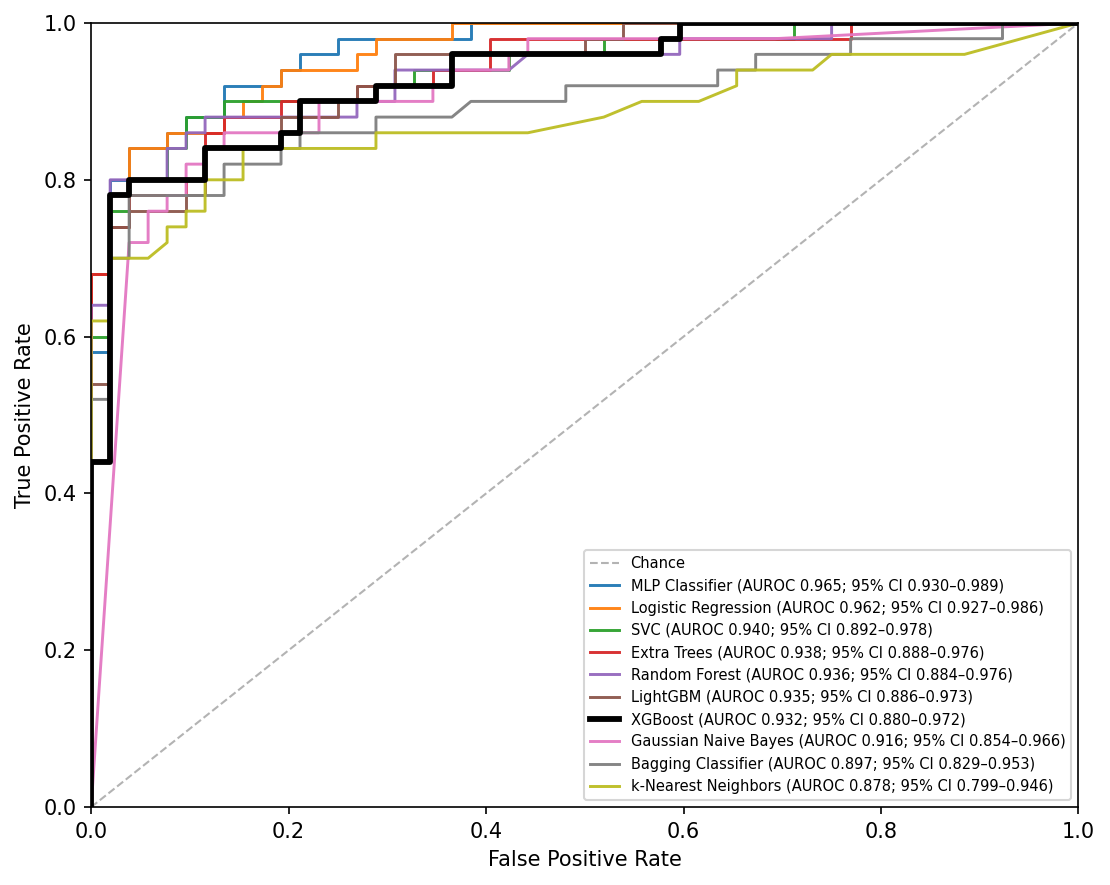

In [2]:
# ============================ Robust CV (OOF wie Code 1) + ROC (OOF) + Metriktabelle ============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, recall_score, precision_score,
    balanced_accuracy_score, brier_score_loss, log_loss, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis


# ---------------- Utilities ----------------
def proba_or_decision(model, X):
    """Bevorzuge predict_proba; sonst decision_function -> auf (0,1) mappen; sonst harte Labels."""
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        s_min, s_max = np.min(s), np.max(s)
        if s_max - s_min < 1e-12:
            return np.full_like(s, 0.5, dtype=float)
        return (s - s_min) / (s_max - s_min)
    return (model.predict(X) == 1).astype(float)

def percentile_ci(arr, lo=2.5, hi=97.5):
    a = np.asarray(arr, dtype=float)
    return float(np.percentile(a, lo)), float(np.percentile(a, hi))

def bootstrap_ci_metric(y, p, thr=0.5, B=2000, seed=42):
    """
    Bootstrap-KI für Schwellenmetriken (Acc, F1, Prec, Rec)
    sowie Brier und LogLoss – alles auf OOF-Samples.
    """
    rng = np.random.default_rng(seed)
    y = np.asarray(y, dtype=int)
    p = np.asarray(p, dtype=float)
    idx = np.arange(len(y))

    def metrics(y_, p_):
        yhat = (p_ >= thr).astype(int)
        return {
            "acc":  accuracy_score(y_, yhat),
            "f1":   f1_score(y_, yhat, zero_division=0),
            "prec": precision_score(y_, yhat, zero_division=0),
            "rec":  recall_score(y_, yhat, zero_division=0),
            "brier": brier_score_loss(y_, p_),
            "logloss": log_loss(y_, p_)
        }

    pt = metrics(y, p)
    ACC, F1, PR, RE, BR, LL = [], [], [], [], [], []
    for _ in range(int(B)):
        s = rng.choice(idx, size=len(idx), replace=True)
        m = metrics(y[s], p[s])
        ACC.append(m["acc"]); F1.append(m["f1"]); PR.append(m["prec"]); RE.append(m["rec"])
        BR.append(m["brier"]); LL.append(m["logloss"])

    def wrap(point, vec):
        lo, hi = percentile_ci(vec)
        return (float(point), float(lo), float(hi))

    return {
        "acc":     wrap(pt["acc"],    ACC),
        "f1":      wrap(pt["f1"],     F1),
        "prec":    wrap(pt["prec"],   PR),
        "rec":     wrap(pt["rec"],    RE),
        "brier":   wrap(pt["brier"],  BR),
        "logloss": wrap(pt["logloss"],LL),
    }

def bootstrap_ci_auc(y, p, B=2000, seed=42):
    """95%-KI für AUROC per Bootstrap auf OOF-Samples (wie Code 1)."""
    rng = np.random.default_rng(seed)
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    idx = np.arange(len(y))
    pt = roc_auc_score(y, p)
    boots = []
    for _ in range(int(B)):
        s = rng.choice(idx, size=len(idx), replace=True)
        boots.append(roc_auc_score(y[s], p[s]))
    lo, hi = np.percentile(boots, [2.5, 97.5]).astype(float)
    return float(pt), float(lo), float(hi)

def youden_threshold(y_true, p_score):
    """Youden-Index (Tpr - Fpr) -> beste Schwelle auf Trainingsdaten."""
    fpr, tpr, thr = roc_curve(y_true, p_score)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def get_oof_scores_and_metrics(base_estimator, X_df: pd.DataFrame, y_vec, n_splits=5, n_repeats=10, random_state=42):
    """
    Repliziert Code-1-Logik:
      - MinMaxScaler pro Fold
      - OOF-Scores fürs komplette Dataset
      - Fold-Statistiken mit train-seitig optimierter Schwelle (Youden):
        * Train Accuracy (Train-Threshold auf Train-Fold)
        * Test Accuracy / BalAcc / F1 / Recall / Precision (Train-Threshold auf Test-Fold)
    """
    le = LabelEncoder()
    y = le.fit_transform(y_vec)
    if len(le.classes_) != 2:
        raise ValueError("Dieses Setup erwartet binäre Klassifikation (2 Klassen).")

    rkf = RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=random_state)
    X = X_df.values

    oof_scores = np.zeros(len(X), dtype=float)
    oof_count  = np.zeros(len(X), dtype=int)

    # Fold-Statistiken sammeln (Youden pro Train-Fold)
    acc_tr_list, acc_te_list = [], []
    bacc_list, f1_list, rec_list, prec_list = [], [], [], []

    for tr, te in rkf.split(X, y):
        Xtr, Xte = X[tr], X[te]
        ytr, yte = y[tr], y[te]

        scaler = MinMaxScaler()
        Xtr_sc = scaler.fit_transform(Xtr)
        Xte_sc = scaler.transform(Xte)

        est = base_estimator
        est.fit(Xtr_sc, ytr)

        # Probabilitäten
        p_tr = proba_or_decision(est, Xtr_sc)
        p_te = proba_or_decision(est, Xte_sc)
        p_te = np.clip(p_te, 1e-7, 1-1e-7)

        # ---- Youden-Schwelle nur auf TRAIN bestimmen ----
        thr = youden_threshold(ytr, p_tr)

        # Train- und Test-Metriken mit der train-seitigen Schwelle
        yhat_tr = (p_tr >= thr).astype(int)
        acc_tr_list.append(accuracy_score(ytr, yhat_tr))

        yhat_te = (p_te >= thr).astype(int)
        acc_te_list.append(accuracy_score(yte, yhat_te))
        bacc_list.append(balanced_accuracy_score(yte, yhat_te))
        f1_list.append(f1_score(yte, yhat_te, zero_division=0))
        rec_list.append(recall_score(yte, yhat_te, zero_division=0))
        prec_list.append(precision_score(yte, yhat_te, zero_division=0))

        # OOF aggregieren (für AUROC/Brier/LogLoss)
        oof_scores[te] += p_te
        oof_count[te]  += 1

    # Mittelung, wo mehrfach vorhergesagt
    m = oof_count > 0
    oof_scores[m] = oof_scores[m] / oof_count[m]

    # OOF-AUROC + ROC-Kurve
    auroc = roc_auc_score(y, oof_scores)
    fpr, tpr, _ = roc_curve(y, oof_scores)

    fold_df = pd.DataFrame({
        "acc_tr": acc_tr_list,
        "acc_te": acc_te_list,
        "bacc":   bacc_list,
        "f1":     f1_list,
        "rec":    rec_list,
        "prec":   prec_list
    })

    return {
        "y_true": y,
        "oof_scores": oof_scores,
        "fpr": fpr,
        "tpr": tpr,
        "oof_auroc": auroc,
        "fold_metrics": fold_df
    }

def fmt_ci(mean, lo, hi):
    return f"{mean:.3f} ({lo:.3f}–{hi:.3f})"

def display_scrollable(df_view, height=700):
    html = (
        f'<div style="max-height:{height}px; overflow:auto; border:1px solid #ccc; '
        f'padding:6px; background:transparent;">'
        + df_view.to_html(index=False, border=0)
        + '</div>'
    )
    display(HTML(html))


# ─────────────────────────────── Main-Block ───────────────────────────────
if __name__ == "__main__":
    pd.set_option("display.width", 220)

    file_path = r"K:\Team\Böhmer_Michael\TSA\ML\Basistabelle\Basistabelle_5_bis_14_PostOP\Basistabelle_5_bis_14_PostOP.xlsx"
    target_col = "Verletzungsstatus"

    try:
        df = pd.read_excel(file_path)
        if target_col not in df.columns:
            raise ValueError(f"Zielvariable '{target_col}' nicht in Datei gefunden.")

        y = df[target_col]
        X_df = df.drop(columns=[target_col]).select_dtypes(include=[np.number]).copy()
        if X_df.shape[1] == 0:
            raise ValueError("Keine numerischen Features gefunden.")

        # Modelle (LogReg wie in Code 1: liblinear + MinMax)
        models = {
            "Logistic Regression": LogisticRegression(solver="liblinear", penalty="l2", C=1.0,
                                                      class_weight=None, max_iter=200, random_state=42),
            #"Decision Tree": DecisionTreeClassifier(random_state=42),
            "Random Forest": RandomForestClassifier(random_state=42),
            #"Gradient Boosting": GradientBoostingClassifier(random_state=42),
            "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, use_label_encoder=False),
            "LightGBM": LGBMClassifier(verbose=-1, random_state=42),
            "SVC": SVC(probability=True, random_state=42),
            "k-Nearest Neighbors": KNeighborsClassifier(),
            "MLP Classifier": MLPClassifier(max_iter=1000, random_state=42),
            "Gaussian Naive Bayes": GaussianNB(),
            #"Linear Discriminant Analysis": LinearDiscriminantAnalysis(),
            #"Quadratic Discriminant Analysis": QuadraticDiscriminantAnalysis(),
            "Bagging Classifier": BaggingClassifier(random_state=42),
            "Extra Trees": ExtraTreesClassifier(random_state=42),
        }

        cv_params = dict(n_splits=5, n_repeats=10, random_state=42)

        # Sammeln: OOF-Ergebnisse + Fold-Statistiken (mit train-seitiger Youden-Schwelle)
        oof_results = {}
        for name, mdl in models.items():
            print(f"Validiere Modell (OOF): {name}")
            oof_results[name] = get_oof_scores_and_metrics(mdl, X_df, y, **cv_params)

        # Bootstrap-KIs aus OOF (AUROC + Brier + LogLoss) und Fold-aggregation (Train/Test mit train-optimierter Schwelle)
        summary_rows = []
        auc_for_sort = {}
        for name, res in oof_results.items():
            y_true = res["y_true"]
            p_oof  = res["oof_scores"]

            # AUROC (OOF) + 95%-KI (Bootstrap)
            auroc_pt, auroc_lo, auroc_hi = bootstrap_ci_auc(y_true, p_oof, B=2000, seed=42)
            auc_for_sort[name] = auroc_pt

            # Brier/LogLoss (OOF) via Bootstrap
            ci_pack = bootstrap_ci_metric(y_true, p_oof, thr=0.5, B=2000, seed=42)
            brier_pt, brier_lo, brier_hi       = ci_pack["brier"]
            logloss_pt, logloss_lo, logloss_hi = ci_pack["logloss"]

            # Fold-basierte Verteilungen (Train/Test mit train-seitiger Youden-Schwelle)
            fm = res["fold_metrics"]
            acc_tr_mean = fm["acc_tr"].mean(); acc_tr_lo, acc_tr_hi = percentile_ci(fm["acc_tr"])
            acc_te_mean = fm["acc_te"].mean(); acc_te_lo, acc_te_hi = percentile_ci(fm["acc_te"])
            bacc_mean   = fm["bacc"].mean();   bacc_lo,   bacc_hi   = percentile_ci(fm["bacc"])
            f1_mean     = fm["f1"].mean();     f1_lo,     f1_hi     = percentile_ci(fm["f1"])
            rec_mean    = fm["rec"].mean();    rec_lo,    rec_hi    = percentile_ci(fm["rec"])
            prec_mean   = fm["prec"].mean();   prec_lo,   prec_hi   = percentile_ci(fm["prec"])

            summary_rows.append({
                "Model": name,
                "Train Accuracy": fmt_ci(acc_tr_mean, acc_tr_lo, acc_tr_hi),
                "Test Accuracy":  fmt_ci(acc_te_mean, acc_te_lo, acc_te_hi),
                "Balanced Acc.":  fmt_ci(bacc_mean,   bacc_lo,   bacc_hi),
                "F1 Score":       fmt_ci(f1_mean,     f1_lo,     f1_hi),
                "Recall":         fmt_ci(rec_mean,    rec_lo,    rec_hi),
                "Precision":      fmt_ci(prec_mean,   prec_lo,   prec_hi),
                "ROC-AUC (OOF)":  f"{auroc_pt:.3f} ({auroc_lo:.3f}–{auroc_hi:.3f})",
                "Brier (OOF)":    f"{brier_pt:.3f} ({brier_lo:.3f}–{brier_hi:.3f})",
                "LogLoss (OOF)":  f"{logloss_pt:.3f} ({logloss_lo:.3f}–{logloss_hi:.3f})",
            })

        # Tabelle sortieren nach AUROC (OOF)
        df_view = pd.DataFrame(summary_rows)
        df_view = df_view.iloc[df_view["Model"].map(auc_for_sort).sort_values(ascending=False).index].reset_index(drop=True)

        # Scrollbare Darstellung
        html = (
            f'<div style="max-height:700px; overflow:auto; border:1px solid #ccc; padding:6px; background:transparent;">'
            + df_view.to_html(index=False, border=0)
            + '</div>'
        )
        display(HTML(html))

        # ── ROC: OOF-Kurven + AUROC (OOF) + 95%-KI (Bootstrap), Legende sortiert, LogReg schwarz ──
        fig, ax = plt.subplots(figsize=(7.5, 6.0), dpi=150)
        ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.0, color="0.7", label="Chance")

        for name in sorted(oof_results.keys(), key=lambda n: auc_for_sort[n], reverse=True):
            res = oof_results[name]
            auroc_pt, auroc_lo, auroc_hi = bootstrap_ci_auc(res["y_true"], res["oof_scores"], B=2000, seed=42)
            label = f"{name} (AUROC {auroc_pt:.3f}; 95% CI {auroc_lo:.3f}–{auroc_hi:.3f})"
            if "xgboost" in name.strip().lower():
                ax.plot(res["fpr"], res["tpr"], label=label, color="black", linewidth=2.8, zorder=10)
            else:
                ax.plot(res["fpr"], res["tpr"], label=label, linewidth=1.4, alpha=0.95)

            # if name.strip().lower() in {"logistic regression", "logreg", "lr"}:
            #     ax.plot(res["fpr"], res["tpr"], label=label, color="black", linewidth=2.8, zorder=10)
            # else:
            #     ax.plot(res["fpr"], res["tpr"], label=label, linewidth=1.4, alpha=0.95)

        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
        #ax.set_title("ROC (OOF across 5×10 CV) — all models")
        ax.legend(loc="lower right", frameon=True, fontsize=7)
        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print("Die Datei wurde nicht gefunden. Bitte überprüfe den Pfad.")
    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")
